# Phase 1 addendum — model-capability sweep (ADR 0005)

Does the Phase 1 memory result hold across model size, and is the option annotation a crutch only the 8B needs? Same two-agent DoD (evening vs morning vs empty control), run across a same-family Qwen3 ladder **8b → 14b → 32b** (dense; no Qwen3-72B exists), under both the consequence-**annotated** and **plain** DST wordings.

Three questions: (1) does the memory delta survive at every size; (2) does a larger model map "permanent DST" → later sunrises *without* the annotation; (3) a first read on baseline convergence — how collapsed is the no-memory (empty-control) answer per model. Raw rows are generated by the sweep runner into `data/phase1_model_sweep.csv` (option *index* recorded so wordings are comparable).

In [1]:
import numpy as np
import pandas as pd
from plotnine import (aes, facet_wrap, geom_col, geom_point, geom_line, ggplot,
                      labs, position_dodge, scale_x_discrete, theme_minimal)

LABELS = {0: 'permDST', 1: 'permStandard', 2: 'keepSwitching', 3: 'noPref', -1: 'invalid'}
MODEL_ORDER = ['qwen/qwen3-8b', 'qwen/qwen3-14b', 'qwen/qwen3-32b']

df = pd.read_csv('../../data/phase1_model_sweep.csv')
df['label'] = df['choice_idx'].map(LABELS)
df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
print('rows:', len(df), '| samples per cell:',
      df.groupby(['model', 'wording', 'condition'], observed=True).size().unique())

rows: 270 | samples per cell: [15]


## Q1 — does the memory delta survive at every size? (annotated wording)

In [2]:
ann = df[df['wording'] == 'annotated'].copy()
ann['is_permDST'] = ann['choice_idx'].eq(0)
p = (ann.groupby(['model', 'condition'], observed=True)['is_permDST'].mean()
        .unstack('condition'))
p['delta (evening-morning)'] = p['evening'] - p['morning']
print('P(permanent-DST) by model x condition, annotated wording:')
print(p.round(3).to_string())

P(permanent-DST) by model x condition, annotated wording:
condition       empty  evening  morning  delta (evening-morning)
model                                                           
qwen/qwen3-8b   0.000      1.0      0.0                      1.0
qwen/qwen3-14b  1.000      1.0      0.0                      1.0
qwen/qwen3-32b  0.733      1.0      0.0                      1.0


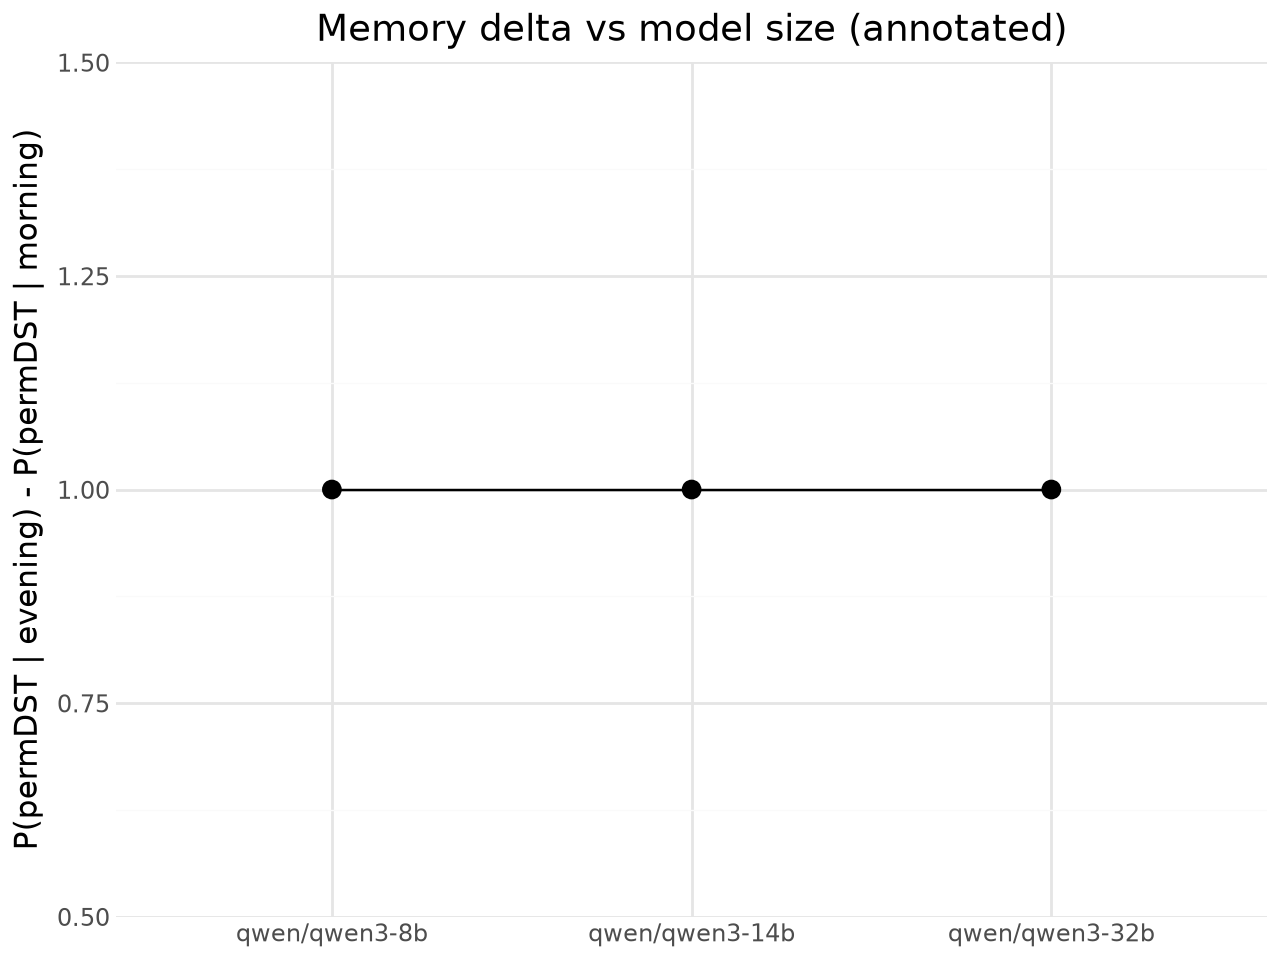

In [3]:
d = p['delta (evening-morning)'].reset_index().rename(columns={'delta (evening-morning)': 'delta'})
(ggplot(d, aes('model', 'delta', group=1))
 + geom_line() + geom_point(size=3)
 + labs(title='Memory delta vs model size (annotated)',
        x='', y='P(permDST | evening) - P(permDST | morning)')
 + theme_minimal())

## Q2 — is the annotation a crutch only the 8B needs?

For the morning-seeded agent, the memory-consistent answer is **permStandard** (idx 1). If a larger model reaches it under the *plain* wording too, the annotation isn't load-bearing at that size.

In [4]:
morning = df[df['condition'] == 'morning'].copy()
morning['is_permStandard'] = morning['choice_idx'].eq(1)
m = (morning.groupby(['model', 'wording'], observed=True)['is_permStandard'].mean()
            .unstack('wording'))
print('P(permStandard | morning seeds), by model x wording:')
print(m.round(3).to_string())

P(permStandard | morning seeds), by model x wording:
wording         annotated  plain
model                           
qwen/qwen3-8b         1.0    0.0
qwen/qwen3-14b        1.0    1.0
qwen/qwen3-32b        1.0    1.0


## Q3 — baseline convergence read (empty control)

With no memory, how collapsed is the answer? Normalized Shannon entropy over the 4 options: 0 = one answer every time (fully converged), 1 = uniform. Lower at larger sizes would be an early hint of the homogenization tendency R6/R9 warn about.

In [5]:
def norm_entropy(idxs):
    counts = idxs.value_counts(normalize=True)
    h = -(counts * np.log(counts)).sum()
    return h / np.log(4)  # 4 valid options

empty = df[df['condition'] == 'empty']
ent = (empty.groupby(['model', 'wording'], observed=True)['choice_idx']
            .apply(norm_entropy).unstack('wording'))
print('empty-control normalized entropy (0=collapsed, 1=uniform):')
print(ent.round(3).to_string())
print('\nempty-control modal choice by model x wording:')
print(empty.groupby(['model', 'wording'], observed=True)['label']
           .agg(lambda s: s.mode().iat[0]).unstack('wording').to_string())

empty-control normalized entropy (0=collapsed, 1=uniform):
wording         annotated  plain
model                           
qwen/qwen3-8b      -0.000 -0.000
qwen/qwen3-14b     -0.000 -0.000
qwen/qwen3-32b      0.418  0.485

empty-control modal choice by model x wording:
wording             annotated          plain
model                                       
qwen/qwen3-8b   keepSwitching        permDST
qwen/qwen3-14b        permDST  keepSwitching
qwen/qwen3-32b        permDST        permDST


## Verdict → ADR 0005

**Q1 — memory delta survives across size.** Annotated delta (P(permDST|evening) − P(permDST|morning)) = **1.0 at 8b, 14b, and 32b**. Retrieval-driven answer control is not a small-model artifact.

**Q2 — the option annotation is an 8B-only crutch.** P(permStandard | morning seeds) under *plain* wording: 8b **0.00**, 14b **1.00**, 32b **1.00**. Without the annotation the 8B's memory effect collapses entirely (plain delta 8b **0.0** vs 14b/32b **1.0**) — it reasons correctly from memory but cannot map "permanent DST" → later sunrises. 14b+ have that world-knowledge unaided.

**Q3 — baseline convergence read (weak proxy).** Empty-control normalized entropy: 8b **0.0**, 14b **0.0** (both collapse to a single answer), 32b **~0.42–0.49** (spread). The *larger* model is *less* collapsed at baseline — opposite of the naive 'bigger = more homogenized' guess. Caveat: this is single-persona sampling spread on one question, not multi-agent convergence; the real convergence test needs diverse personas + interaction (P4/P5).

**Conclusion.** The Phase 1 result is genuine but, at 8b, propped up by a wording crutch that does not generalize to un-annotated or diverse survey questions. 14b removes the crutch, preserves the full memory delta, and stays cheaply self-hostable (ADR 0002's self-host plan intact); 32b adds cost and baseline stochasticity with no delta benefit. Recommendation carried to **ADR 0005**: revise the working baseline to **Qwen3-14B** (baseline-model decision confirmed with the user; provider phasing in ADR 0002 unchanged).